# Dividir Dataset en Train/Validation/Test - Fase 6

**Objetivo:** Dividir el dataset final en 3 conjuntos para entrenamiento

**Dataset:** dataset_safetalk_final.csv (8,564 ejemplos)

**División:**
- Train: 70% (entrenamiento del modelo)
- Validation: 15% (ajuste de hiperparámetros)
- Test: 15% (evaluación final)

**Importante:** División estratificada (mantiene proporción 50/50 en cada conjunto)

---

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Librerias importadas")

Librerias importadas


In [2]:
# Cargar dataset final
df = pd.read_csv('../data/processed/dataset_safetalk_final.csv')

print("="*70)
print("DATASET FINAL CARGADO")
print("="*70)

print(f"\nTotal de ejemplos: {len(df)}")

print("\nPrimeras 5 filas:")
print(df.head())

print("\nInformacion del dataset:")
print(df.info())

print("\nDistribucion de clases:")
print(df['label'].value_counts().sort_index())

DATASET FINAL CARGADO

Total de ejemplos: 8457

Primeras 5 filas:
                                               texto  label  fuente
0  Ismael es egocentrico porque se vuelve loca si...      0  zenodo
1  ..ya tardaba en salir quien pronunciase nombre...      0  zenodo
2  (Esto no es un discurso político y razonado, o...      0  zenodo
3  Muy despreciados,siiii,pero todos vestidos de ...      1  zenodo
4  marica explicame porque a veces no te entiendo...      1  zenodo

Informacion del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8457 entries, 0 to 8456
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   texto   8457 non-null   str  
 1   label   8457 non-null   int64
 2   fuente  8457 non-null   str  
dtypes: int64(1), str(2)
memory usage: 980.8 KB
None

Distribucion de clases:
label
0    4260
1    4197
Name: count, dtype: int64


In [3]:
# Dividir en train+val (85%) y test (15%)
# stratify=df['label'] mantiene la proporcion 50/50 en ambos conjuntos

X = df['texto']
y = df['label']

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, 
    y, 
    test_size=0.15,
    random_state=42,
    stratify=y
)

print("="*70)
print("DIVISION TRAIN+VAL vs TEST")
print("="*70)

print(f"\nTrain+Val: {len(X_train_val)} ejemplos ({len(X_train_val)/len(df)*100:.1f}%)")
print(f"Test: {len(X_test)} ejemplos ({len(X_test)/len(df)*100:.1f}%)")

print(f"\nDistribucion en Train+Val:")
print(y_train_val.value_counts().sort_index())

print(f"\nDistribucion en Test:")
print(y_test.value_counts().sort_index())

DIVISION TRAIN+VAL vs TEST

Train+Val: 7188 ejemplos (85.0%)
Test: 1269 ejemplos (15.0%)

Distribucion en Train+Val:
label
0    3621
1    3567
Name: count, dtype: int64

Distribucion en Test:
label
0    639
1    630
Name: count, dtype: int64


In [4]:
# Dividir train+val en train (70% del total) y val (15% del total)
# 70/85 = 0.8235

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.1765,
    random_state=42,
    stratify=y_train_val
)

print("="*70)
print("DIVISION FINAL: TRAIN / VALIDATION / TEST")
print("="*70)

total = len(df)

print(f"\nTrain: {len(X_train)} ejemplos ({len(X_train)/total*100:.1f}%)")
print(f"Validation: {len(X_val)} ejemplos ({len(X_val)/total*100:.1f}%)")
print(f"Test: {len(X_test)} ejemplos ({len(X_test)/total*100:.1f}%)")
print(f"\nTOTAL: {len(X_train) + len(X_val) + len(X_test)} ejemplos")

print("\n" + "-"*70)
print("DISTRIBUCION POR CONJUNTO")
print("-"*70)

print(f"\nTrain:")
print(y_train.value_counts().sort_index())
print(f"Balance: {y_train.value_counts()[0]} vs {y_train.value_counts()[1]}")

print(f"\nValidation:")
print(y_val.value_counts().sort_index())
print(f"Balance: {y_val.value_counts()[0]} vs {y_val.value_counts()[1]}")

print(f"\nTest:")
print(y_test.value_counts().sort_index())
print(f"Balance: {y_test.value_counts()[0]} vs {y_test.value_counts()[1]}")

DIVISION FINAL: TRAIN / VALIDATION / TEST

Train: 5919 ejemplos (70.0%)
Validation: 1269 ejemplos (15.0%)
Test: 1269 ejemplos (15.0%)

TOTAL: 8457 ejemplos

----------------------------------------------------------------------
DISTRIBUCION POR CONJUNTO
----------------------------------------------------------------------

Train:
label
0    2982
1    2937
Name: count, dtype: int64
Balance: 2982 vs 2937

Validation:
label
0    639
1    630
Name: count, dtype: int64
Balance: 639 vs 630

Test:
label
0    639
1    630
Name: count, dtype: int64
Balance: 639 vs 630


In [5]:
# Crear DataFrames para cada conjunto

df_train = pd.DataFrame({
    'texto': X_train.values,
    'label': y_train.values
})

df_val = pd.DataFrame({
    'texto': X_val.values,
    'label': y_val.values
})

df_test = pd.DataFrame({
    'texto': X_test.values,
    'label': y_test.values
})

# Guardar en archivos CSV
df_train.to_csv('../data/processed/train.csv', index=False, encoding='utf-8')
df_val.to_csv('../data/processed/val.csv', index=False, encoding='utf-8')
df_test.to_csv('../data/processed/test.csv', index=False, encoding='utf-8')

print("="*70)
print("CONJUNTOS GUARDADOS")
print("="*70)

print("\nArchivos creados:")
print("   1. data/processed/train.csv")
print("   2. data/processed/val.csv")
print("   3. data/processed/test.csv")

print("\nTamaños:")
print(f"   Train: {len(df_train)} ejemplos")
print(f"   Validation: {len(df_val)} ejemplos")
print(f"   Test: {len(df_test)} ejemplos")

print("\nPrimeras 3 filas de Train:")
print(df_train.head(3))

print("\nPrimeras 3 filas de Validation:")
print(df_val.head(3))

print("\nPrimeras 3 filas de Test:")
print(df_test.head(3))

CONJUNTOS GUARDADOS

Archivos creados:
   1. data/processed/train.csv
   2. data/processed/val.csv
   3. data/processed/test.csv

Tamaños:
   Train: 5919 ejemplos
   Validation: 1269 ejemplos
   Test: 1269 ejemplos

Primeras 3 filas de Train:
                                               texto  label
0  Con esa actitud es normal que nadie te quiera,...      1
1  No me roban en VILLA LUGANO saliendo de estudi...      1
2  Tienes una imagen penosa, búscate un hobby, to...      1

Primeras 3 filas de Validation:
                                               texto  label
0  Te voy a encontrar y te haré pagar lo que has ...      1
1  ¿Por qué siempre tienes que ser tan inútil en ...      1
2  mas claro no canta un gallo no se que espera l...      1

Primeras 3 filas de Test:
                                               texto  label
0  porque mitad de mis mutuals son gringos mirad ...      0
1             Que tío más subnormal el de first date      1
2  Acabo de apuntar en mi lista de co

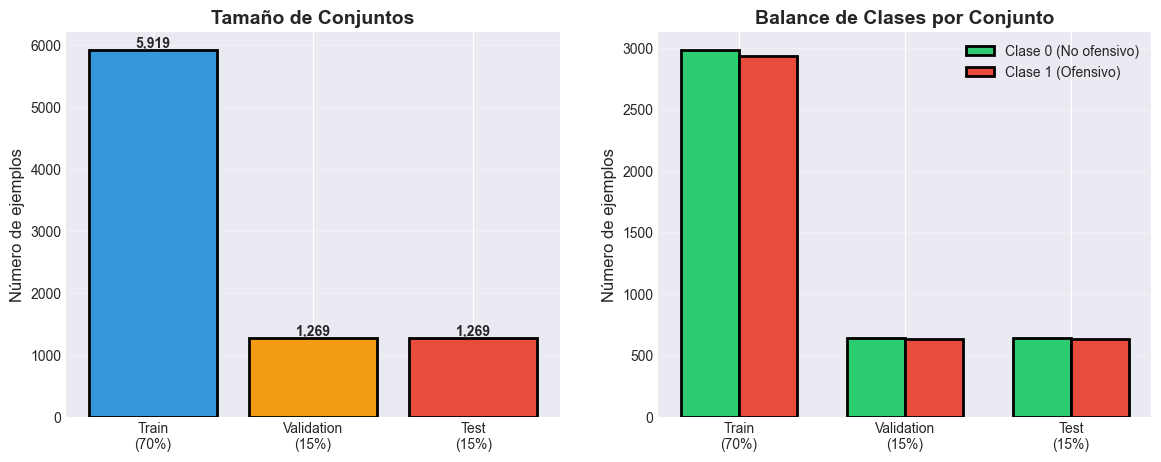

In [8]:
# Crear visualizacion final

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Tamaño de cada conjunto
tamaños = [len(df_train), len(df_val), len(df_test)]
nombres = ['Train\n(70%)', 'Validation\n(15%)', 'Test\n(15%)']
colores = ['#3498db', '#f39c12', '#e74c3c']

axes[0].bar(nombres, tamaños, color=colores, edgecolor='black', linewidth=2)
axes[0].set_title('Tamaño de Conjuntos', fontweight='bold', fontsize=14)
axes[0].set_ylabel('Número de ejemplos', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(tamaños):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Grafico 2: Balance de clases en cada conjunto
x = np.arange(3)
ancho = 0.35

clase_0 = [
    len(df_train[df_train['label']==0]),
    len(df_val[df_val['label']==0]),
    len(df_test[df_test['label']==0])
]

clase_1 = [
    len(df_train[df_train['label']==1]),
    len(df_val[df_val['label']==1]),
    len(df_test[df_test['label']==1])
]

axes[1].bar(x - ancho/2, clase_0, ancho, label='Clase 0 (No ofensivo)', 
            color='#2ecc71', edgecolor='black', linewidth=2)
axes[1].bar(x + ancho/2, clase_1, ancho, label='Clase 1 (Ofensivo)', 
            color='#e74c3c', edgecolor='black', linewidth=2)

axes[1].set_title('Balance de Clases por Conjunto', fontweight='bold', fontsize=14)
axes[1].set_ylabel('Número de ejemplos', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.show()


In [11]:
print("="*70)
print("RESUMEN FINAL")
print("="*70)

print("\n DATASET DIVIDIDO EXITOSAMENTE")

print("\n" + "-"*70)
print("ARCHIVOS CREADOS")
print("-"*70)

print("\n1. data/processed/train.csv")
print(f"   - Ejemplos: {len(df_train):,}")
print(f"   - Clase 0: {len(df_train[df_train['label']==0]):,}")
print(f"   - Clase 1: {len(df_train[df_train['label']==1]):,}")
print(f"   - Uso: Entrenamiento del modelo")

print("\n2. data/processed/val.csv")
print(f"   - Ejemplos: {len(df_val):,}")
print(f"   - Clase 0: {len(df_val[df_val['label']==0]):,}")
print(f"   - Clase 1: {len(df_val[df_val['label']==1]):,}")
print(f"   - Uso: Ajuste de hiperparametros y deteccion de overfitting")

print("\n3. data/processed/test.csv")
print(f"   - Ejemplos: {len(df_test):,}")
print(f"   - Clase 0: {len(df_test[df_test['label']==0]):,}")
print(f"   - Clase 1: {len(df_test[df_test['label']==1]):,}")
print(f"   - Uso: Evaluacion final del modelo (NUNCA se usa en entrenamiento)")

print("\n" + "-"*70)
print("ESTADISTICAS GENERALES")
print("-"*70)

total_ejemplos = len(df_train) + len(df_val) + len(df_test)
print(f"\nTotal de ejemplos: {total_ejemplos:,}")
print(f"Division: 70% / 15% / 15%")
print(f"Balance general: {len(df[df['label']==0]):,} clase 0 vs {len(df[df['label']==1]):,} clase 1")
print(f"Ratio: {len(df[df['label']==0])/len(df[df['label']==1]):.2f}:1")

RESUMEN FINAL

 DATASET DIVIDIDO EXITOSAMENTE

----------------------------------------------------------------------
ARCHIVOS CREADOS
----------------------------------------------------------------------

1. data/processed/train.csv
   - Ejemplos: 5,919
   - Clase 0: 2,982
   - Clase 1: 2,937
   - Uso: Entrenamiento del modelo

2. data/processed/val.csv
   - Ejemplos: 1,269
   - Clase 0: 639
   - Clase 1: 630
   - Uso: Ajuste de hiperparametros y deteccion de overfitting

3. data/processed/test.csv
   - Ejemplos: 1,269
   - Clase 0: 639
   - Clase 1: 630
   - Uso: Evaluacion final del modelo (NUNCA se usa en entrenamiento)

----------------------------------------------------------------------
ESTADISTICAS GENERALES
----------------------------------------------------------------------

Total de ejemplos: 8,457
Division: 70% / 15% / 15%
Balance general: 4,260 clase 0 vs 4,197 clase 1
Ratio: 1.02:1
